In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,  confusion_matrix, classification_report

df= pd.read_csv("../data/raw/StudentsPerformance.csv")
df.columns = df.columns.str.replace(' ', '_').str.replace('/', '_')
print(df.head())

   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [5]:
df["Average_Score"] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)
df['at_risk']=  (df['Average_Score'] < 40).astype(int)
print(df['at_risk'].value_counts())
print(f"\nAt-risk percentage: {df['at_risk'].mean()*100:.2f}%")



at_risk
0    970
1     30
Name: count, dtype: int64

At-risk percentage: 3.00%


In [7]:
df_model = df.copy()
catergorical_cols = ['gender','race_ethnicity','parental_level_of_education','lunch','test_preparation_course']
le_dict ={}
for col in catergorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
df_model.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Average_Score,at_risk
0,0,1,1,1,1,72,72,74,72.666667,0
1,0,2,4,1,0,69,90,88,82.333333,0
2,0,1,3,1,1,90,95,93,92.666667,0
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,0


In [8]:
feature_cols = ['gender','race_ethnicity', 'parental_level_of_education','lunch','test_preparation_course', 'math_score', 'reading_score', 'writing_score']
x = df_model[feature_cols]
y = df_model['at_risk']
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size= 0.2, random_state=42, stratify=y)
print("Training Shape:",X_train.shape)
print("Testing Shape:",X_test.shape)
print("Train at-risk %:", y_train.mean()*100)
print("Test at_risk %:", y_test.mean()*100)

Training Shape: (800, 8)
Testing Shape: (200, 8)
Train at-risk %: 3.0
Test at_risk %: 3.0


In [10]:
models={
    'Logisitic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state = 42,eval_metric = 'logloss')
}
results ={}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    results[name] ={
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred,zero_division=0),
        "Recall": recall_score(y_test,y_pred,zero_division=0),
        "F1-Score": f1_score(y_test,y_pred,zero_division=0)
    }
    print(f"\n---{name}---")
    print(classification_report(y_test,y_pred,zero_division=0))
results_df = pd.DataFrame(results).T
print(results_df)


---Logisitic Regression---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       194
           1       1.00      1.00      1.00         6

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


---Random Forest---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       194
           1       1.00      1.00      1.00         6

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


---XGBoost---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       194
           1       0.80      0.67      0.73         6

    accuracy                           0.98       200
   macro avg       0.89      0.83      0.86       200
weighted a

In [12]:
best_model_name = results_df['Recall'].idxmax()
print(f"Selected model: {best_model_name}")
best_model = models[best_model_name]


Selected model: Logisitic Regression


Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


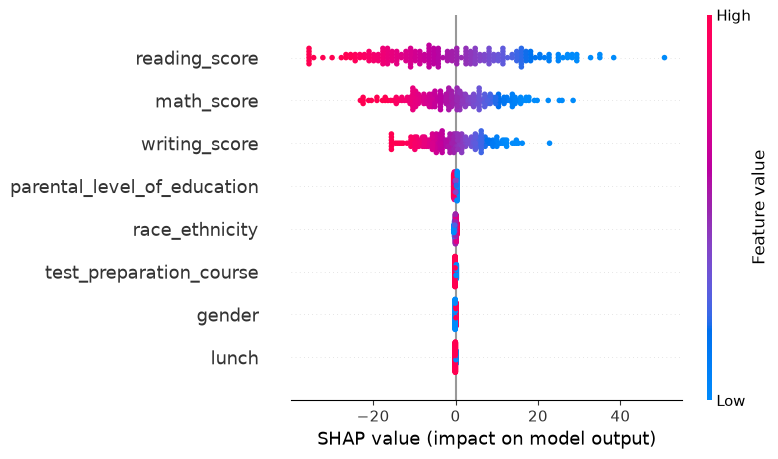

In [13]:
import shap

# SHAP works differently for tree models vs linear models
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train)

shap_values = explainer.shap_values(X_test)

# Summary plot - shows which features matter most overall
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)


In [14]:
# Pick one student and explain their prediction
sample_idx = 0
sample = X_test.iloc[[sample_idx]]

prediction = best_model.predict(sample)[0]
print(f"Predicted at-risk: {prediction}")
print(f"Actual at-risk: {y_test.iloc[sample_idx]}")

# Force plot for this individual
if best_model_name in ['Random Forest', 'XGBoost']:
    shap.force_plot(explainer.expected_value, shap_values[sample_idx], sample, feature_names=feature_cols, matplotlib=True)
    

Predicted at-risk: 0
Actual at-risk: 0


In [15]:
import pickle

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

with open('../models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("Saved:", best_model_name)

Saved: Logisitic Regression
